In [270]:
# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [272]:
data = pd.read_csv('updated_pollution_dataset.csv')

In [274]:
data = data.dropna()  # Option to drop rows with missing values


In [276]:
X = data[['Temperature', 'Humidity','NO2','SO2','CO']]  
y = data['Air Quality']


In [278]:
# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [280]:
# Handling Imbalanced Data 
# Upsample the minority class
data_balanced = pd.concat([X, y], axis=1)
majority = data_balanced[data_balanced['Air Quality'] == data_balanced['Air Quality'].mode()[0]]
minority = data_balanced[data_balanced['Air Quality'] != data_balanced['Air Quality'].mode()[0]]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
data_balanced = pd.concat([majority, minority_upsampled])

In [282]:
# Re-split after balancing
X_balanced = data_balanced.drop('Air Quality', axis=1)
y_balanced = data_balanced['Air Quality']


In [284]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)  # Reduce to 3 principal components
X_pca = pca.fit_transform(X_scaled)

In [286]:
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

In [288]:
# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, 
                           cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [290]:
# Measure training time
start_time = time.time()  # Start timer

In [295]:
# Best Model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [299]:
best_model.fit(X_train, y_train)  # Train the model
end_time = time.time()  # End timer

In [303]:
# Calculate total training time
training_time = end_time - start_time
print(f"Total Training Time: {training_time:.2f} seconds")

Total Training Time: 220.47 seconds


In [305]:
# Model Evaluation
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9525

Classification Report:
               precision    recall  f1-score   support

        Good       0.99      0.99      0.99       422
   Hazardous       0.94      0.76      0.84        67
    Moderate       0.95      0.95      0.95       185
        Poor       0.84      0.93      0.88       126

    accuracy                           0.95       800
   macro avg       0.93      0.91      0.92       800
weighted avg       0.95      0.95      0.95       800



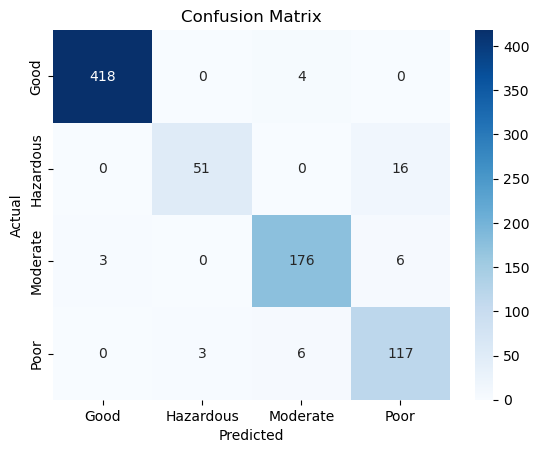

In [307]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [309]:
# Cross-Validation
cv_scores = cross_val_score(best_model, X_balanced, y_balanced, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Cross-Validation Accuracy: 0.95 ± 0.01


In [310]:
# Feature Importance Analysis
importances = best_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

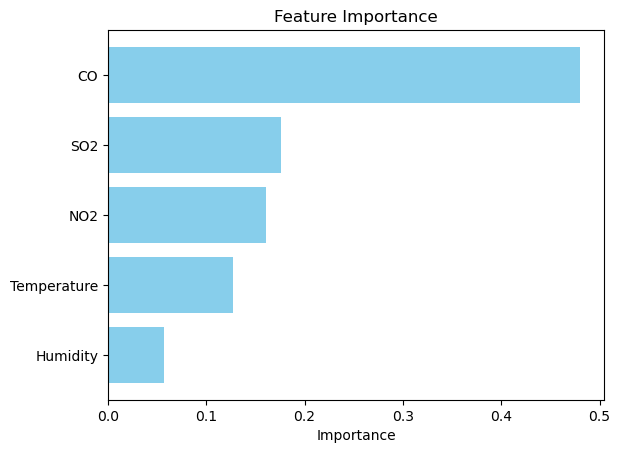

In [311]:
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # Invert y-axis for descending order
plt.show()


In [315]:
# Save the Trained Model 
import joblib
joblib.dump(best_model, "best_random_forest_model.pkl")

['best_random_forest_model.pkl']

In [ ]:
!uvicorn backend:app --host 0.0.0.0 --port 8000 --reload
